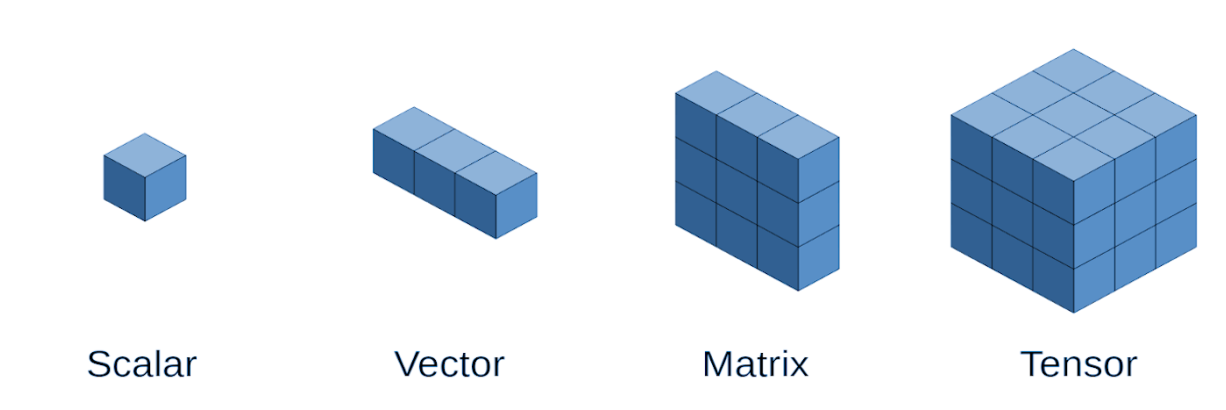

In [1]:
import torch
scalar = torch.tensor(3.14159)
vector = torch.tensor([1, 2, 3])
matrix = torch.ones((2, 3), dtype=torch.float)
tensor = torch.randn((2, 3, 4), dtype=torch.float)
print(scalar)
print(vector)
print(matrix)
print(tensor)

tensor(3.1416)
tensor([1, 2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[[ 0.7226, -0.0141, -1.1148, -1.2249],
         [ 0.1220, -0.9287, -1.4994,  0.6875],
         [ 0.1747, -0.8409, -0.4116,  0.4708]],

        [[ 0.5997,  0.1386, -2.1164, -0.3863],
         [ 0.5092, -0.7835, -0.7307, -0.4492],
         [ 0.2006, -0.9089, -0.2547, -0.2187]]])


In [2]:
print(tensor.size(), tensor.shape)

torch.Size([2, 3, 4]) torch.Size([2, 3, 4])


In [4]:
print(scalar.size(), scalar.shape)

torch.Size([]) torch.Size([])


> **Note:**  
> The `view()` method **only returns a tensor with the desired shape** that **shares the underlying data** with the original tensor.  
> It **does not create a new, independent tensor**.


In [5]:
# We get a tensor with a different shape but it still is
# the SAME tensor
same_matrix = matrix.view(1, 6)
# If we change one of its elements...
same_matrix[0, 1] = 2.
# It changes both variables: matrix and same_matrix
print(matrix)
print(same_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 2., 1., 1., 1., 1.]])


- To **duplicate the data in memory**, use one of the following methods:
  - `new_tensor()`
  - `clone()`

In [6]:
# We can use "new_tensor" method to REALLY copy it into a new one
different_matrix = matrix.new_tensor(matrix.view(1, 6))
# Now, if we change one of its elements...
different_matrix[0, 1] = 3.
# The original tensor (matrix) is left untouched!
# But we get a "warning" from PyTorch telling us
# to use "clone()" instead!
print(matrix)
print(different_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 3., 1., 1., 1., 1.]])


C:\Users\aren\AppData\Local\Temp\ipykernel_26092\823975569.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  different_matrix = matrix.new_tensor(matrix.view(1, 6))


In [7]:
# Let's follow PyTorch's suggestion and use "clone" method
another_matrix = matrix.view(1, 6).clone().detach()
# Again, if we change one of its elements...
another_matrix[0, 1] = 4.
# The original tensor (matrix) is left untouched!
print(matrix)
print(another_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 4., 1., 1., 1., 1.]])


In [8]:
import numpy as np
true_b = 1
true_w = 2
N = 200
np.random.seed(42)
x = np.random.randn(N,1)
e = np.random.randn(N,1) * .2
y = true_b + true_w * x + e
y.shape

(200, 1)

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= .2, random_state= 42)

In [10]:
x_train_tensor = torch.as_tensor(x_train)
x_train.dtype, x_train_tensor.dtype

(dtype('float64'), torch.float64)

- To **cast a tensor to a different type** (e.g., 32-bit float for lower memory usage), use:
  - `float()`


In [11]:
float_tensor = x_train_tensor.float()
float_tensor.dtype

torch.float32

> **Important:**  
> `as_tensor()` returns a tensor that **shares the underlying data** with the original NumPy array.  
> Modifying the NumPy array will **also modify the PyTorch tensor**, and **vice versa** — similar to `view()`.


In [12]:
dummy_array = np.array([1, 2, 3])
dummy_tensor = torch.as_tensor(dummy_array)
# Modifies the numpy array
dummy_array[1] = 0
# Tensor gets modified too...
dummy_tensor

tensor([1, 0, 3], dtype=torch.int32)

- `torch.tensor()` **always creates a copy** of the data.  
  - It **does not share** memory with the original NumPy array.


- To convert a **PyTorch tensor to a NumPy array**, use:
  - `numpy()`


In [14]:
dummy_tensor.numpy()

array([1, 0, 3])

## Defining Your Device

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [15]:
device

'cuda'

In [16]:
torch.cuda.device_count()

1

In [16]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 4070 Ti'

In [17]:
x_tensor = torch.tensor(x, dtype = torch.float32).to(device)
y_tensor = torch.tensor(y,dtype = torch.float32, device = device)

In [18]:
x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

In [19]:
x_tensor.device

device(type='cuda', index=0)

In [20]:
print(type(x_train), type(x_train_tensor), x_train_tensor.type())

<class 'numpy.ndarray'> <class 'torch.Tensor'> torch.cuda.FloatTensor


In [21]:
back_to_numpy = x_train_tensor.numpy()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [22]:
back_to_numpy = x_train_tensor.cpu().numpy()

## Creating Parameters

- A tensor used as a **learnable parameter must have gradients enabled**

In [23]:
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float)
w = torch.randn(1, requires_grad=True, dtype=torch.float)
print(b, w)

tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


In [24]:
# SECOND
# But what if we want to run it on a GPU? We could just
# send them to device, right?
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float).to(device)
w = torch.randn(1, requires_grad=True, dtype=torch.float).to(device)
print(b, w)
# Sorry, but NO! The to(device) "shadows" the gradient...

tensor([0.3367], device='cuda:0', grad_fn=<ToCopyBackward0>) tensor([0.1288], device='cuda:0', grad_fn=<ToCopyBackward0>)


In [25]:
# THIRD
# We can create regular tensors and send them to
# the device (as we did with our data)
torch.manual_seed(42)
b = torch.randn(1, dtype=torch.float).to(device)
w = torch.randn(1, dtype=torch.float).to(device)
# and THEN set them as requiring gradients...
b.requires_grad_()
w.requires_grad_()
print(b, w)

tensor([0.3367], device='cuda:0', requires_grad=True) tensor([0.1288], device='cuda:0', requires_grad=True)


- Methods ending with an underscore (`_`), such as `requires_grad_()`, perform **in-place modifications**:
  - They **modify the underlying variable directly**.


- **Best practice:** Assign tensors to a device **at creation time** to avoid unexpected behavior:
  ```python
  tensor = torch.randn(size, device=device)


In [26]:
# FINAL
# We can specify the device at the moment of creation
# RECOMMENDED!
# Step 0 - Initializes parameters "b" and "w" randomly
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
print(b, w)

tensor([0.1940], device='cuda:0', requires_grad=True) tensor([0.1391], device='cuda:0', requires_grad=True)


In [27]:
w.dtype

torch.float32

In [28]:
b.detach().cpu()

tensor([0.1940])

In [29]:
losses = []
epoch = 50
lr = .5
y_pred = b + w * x_tensor
error = y_pred - y_tensor
loss = .5*(error**2).mean()
loss.backward()
#w = w - lr * w.grad
#b = b - lr * b.grad
# w -= lr * w.grad
# b -= lr * b.grad
with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad
w.grad.zero_()
b.grad.zero_()

tensor([0.], device='cuda:0')

In [30]:
!brew  install graphviz
!pip install torchviz

'brew' is not recognized as an internal or external command,
operable program or batch file.



[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from torchviz import make_dot

In [32]:
make_dot(loss)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [33]:
loss.detach().cpu().item()

1.8242034912109375

In [34]:
losses.append(loss)

In [35]:
losses

[tensor(1.8242, device='cuda:0', grad_fn=<MulBackward0>)]

In [36]:
from torch import optim

In [78]:
torch.manual_seed(42)
b = torch.randn(1,requires_grad=True,device = device)
w = torch.randn(1,requires_grad=True,device = device)

lr = .5
optimizer = optim.SGD([b,w],lr = lr)
losses = []
epoch = 50


for _ in range(epoch):
  y_pred = b + w * x_tensor
  error = y_pred - y_tensor
  loss = .5*(error**2).mean()
  loss.backward()
  #w = w - lr * w.grad
  #b = b - lr * b.grad
  # w -= lr * w.grad
  # b -= lr * b.grad
  # with torch.no_grad():
  #   w -= lr * w.grad
  #   b -= lr * b.grad

  optimizer.step()
  optimizer.zero_grad()
  # w.grad.zero_()
  # b.grad.zero_()
  losses.append(loss.detach().cpu().item())

w,b

(tensor([2.0202], device='cuda:0', requires_grad=True),
 tensor([1.0180], device='cuda:0', requires_grad=True))

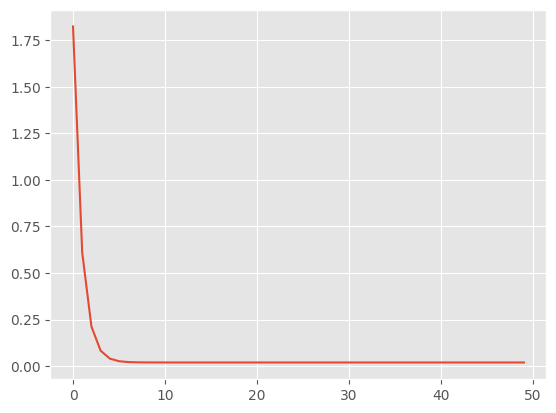

In [80]:
import matplotlib.pyplot as plt
plt.plot(range(epoch),losses)
plt.show()

In [81]:
import torch.nn as nn

In [82]:
loss_fn = nn.MSELoss()

In [91]:
x1 = torch.tensor([1.,2.])
x2 = torch.tensor([3.,3.])
loss_fn(x2,x1)

tensor(2.5000)

In [92]:
((x2-x1)**2)/2

tensor([2.0000, 0.5000])

In [96]:
torch.manual_seed(42)
b = torch.randn(1,requires_grad=True,device = device, dtype = torch.float16)
w = torch.randn(1,requires_grad=True,device = device, dtype = torch.float16)


loss_fn = nn.MSELoss()
lr = .5
optimizer = optim.SGD([b,w],lr = lr)
losses = []
epoch = 50


for _ in range(epoch):
  y_pred = b + w * x_tensor
  loss = loss_fn(y_pred, y_tensor)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  losses.append(loss.detach().cpu().item())

w,b

(tensor([2.0195], device='cuda:0', dtype=torch.float16, requires_grad=True),
 tensor([1.0176], device='cuda:0', dtype=torch.float16, requires_grad=True))

In [104]:
class ManualRegression(nn.Module):

  def __init__(self):
    super().__init__()
    self.b = nn.Parameter(torch.randn(1,requires_grad=True, dtype = torch.float16))
    self.w = nn.Parameter(torch.randn(1,requires_grad=True, dtype = torch.float16))


  def forward(self,x):
    return self.b + self.w * x

In [111]:
torch.manual_seed(42)
model = ManualRegression().to(device)

In [112]:
list(model.parameters())

[Parameter containing:
 tensor([0.3367], device='cuda:0', dtype=torch.float16, requires_grad=True),
 Parameter containing:
 tensor([0.1288], device='cuda:0', dtype=torch.float16, requires_grad=True)]

In [113]:
model.state_dict()

OrderedDict([('b', tensor([0.3367], device='cuda:0', dtype=torch.float16)),
             ('w', tensor([0.1288], device='cuda:0', dtype=torch.float16))])

In [114]:
loss_fn = nn.MSELoss()
lr = .5
optimizer = optim.SGD([b,w],lr = lr)
losses = []
epoch = 50


for _ in range(epoch):
  model.train()
  y_pred = model(x_tensor)
  loss = loss_fn(y_pred, y_tensor)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  losses.append(loss.detach().cpu().item())

In [115]:
class ManualRegression(nn.Module):

  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(in_features= 1, out_features= 1, bias=True)


  def forward(self,x):
    return self.layer(x)

In [117]:
model = ManualRegression().to(device)
list(model.parameters())

[Parameter containing:
 tensor([[-0.4869]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.5873], device='cuda:0', requires_grad=True)]

In [120]:
loss_fn = nn.MSELoss()
lr = .5
optimizer = optim.SGD(model.parameters(),lr = lr)
losses = []
epoch = 50


for _ in range(epoch):
  model.train()
  y_pred = model(x_tensor)
  loss = loss_fn(y_pred, y_tensor)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  losses.append(loss.detach().cpu().item())

In [124]:
val_losses = []

model.eval()
y_pred = model(x_tensor)
loss = loss_fn(y_pred, y_tensor)
val_losses.append(loss.detach().cpu().item())

In [125]:
val_losses

[0.038421228528022766]

In [126]:
y_pred

tensor([[ 2.0214e+00],
        [ 7.3868e-01],
        [ 2.3264e+00],
        [ 4.0948e+00],
        [ 5.4497e-01],
        [ 5.4500e-01],
        [ 4.2083e+00],
        [ 2.5683e+00],
        [ 6.9576e-02],
        [ 2.1141e+00],
        [ 8.1812e-02],
        [ 7.7141e-02],
        [ 1.5068e+00],
        [-2.8472e+00],
        [-2.4666e+00],
        [-1.1792e-01],
        [-1.0281e+00],
        [ 1.6528e+00],
        [-8.1637e-01],
        [-1.8351e+00],
        [ 3.9789e+00],
        [ 5.6189e-01],
        [ 1.1544e+00],
        [-1.8602e+00],
        [-8.1752e-02],
        [ 1.2421e+00],
        [-1.3072e+00],
        [ 1.7770e+00],
        [-1.9540e-01],
        [ 4.2872e-01],
        [-1.9756e-01],
        [ 4.7599e+00],
        [ 9.9073e-01],
        [-1.1188e+00],
        [ 2.6797e+00],
        [-1.4483e+00],
        [ 1.4399e+00],
        [-2.9409e+00],
        [-1.6652e+00],
        [ 1.4157e+00],
        [ 2.5098e+00],
        [ 1.3642e+00],
        [ 7.8437e-01],
        [ 4

In [123]:
losses

[5.566901206970215,
 0.1567985862493515,
 0.04098590835928917,
 0.038476791232824326,
 0.03842243179678917,
 0.03842125087976456,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.038421228528022766,
 0.0384212285280227

In [46]:
w.grad

<ipython-input-46-d01581d16022>:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  w.grad


In [36]:
b.grad, w.grad

(tensor([-0.7473], device='cuda:0'), tensor([-1.5918], device='cuda:0'))

In [38]:
b.grad, w.grad

(tensor([-1.4945], device='cuda:0'), tensor([-3.1836], device='cuda:0'))

In [40]:
b.grad, w.grad

(tensor([-2.2418], device='cuda:0'), tensor([-4.7754], device='cuda:0'))

In [42]:
w.grad.zero_()

tensor([0.], device='cuda:0')

In [43]:
w.grad

tensor([0.], device='cuda:0')